## Customer Churn Prediction: 
     1. Project Goal
     2. Data Loading & Preprocessing
     3. Exploratory Data Analysis (EDA)
     4. Model Training & Evaluation


## 1. Project Goal:
Build and compare three classification models - AdaBoost, Random Forest, and Logistic Regression - to identify the most effective tool for predicting churn.

## 2. Data Loading & Preprocessing

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn import model_selection
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, precision_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)

# Set plot style
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 100

In [20]:
#laod dataset
df = pd.read_csv('customer_churn_dataset-testing-master.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nData types:\n{df.dtypes}')
print(f'\nFirst 3 rows:\n{df.head(3)}')

print('Check missing value in Dataset')
print(df.isnull().sum())

# Feature Selection & Encoding
#Dropped ('Churn', 'CustomerID', 'Last Interaction', 'Total Spend') for reduce noise, and focusing on behavior frequency and contract type 
X = df.drop(['Churn', 'CustomerID', 'Last Interaction', 'Total Spend'], axis = 1)
y = df['Churn']

X_encodec = pd.get_dummies(X,columns=['Gender','Subscription Type','Contract Length'])
X_train, X_test, y_train, y_test = model_selection.train_test_split(X_encodec,y,test_size= 0.2, random_state= 42,stratify=y)

Dataset shape: (64374, 12)

Missing values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

Data types:
CustomerID           int64
Age                  int64
Gender                 str
Tenure               int64
Usage Frequency      int64
Support Calls        int64
Payment Delay        int64
Subscription Type      str
Contract Length        str
Total Spend          int64
Last Interaction     int64
Churn                int64
dtype: object

First 3 rows:
   CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0           1   22  Female      25               14              4   
1           2   41  Female      28               28              7   
2           3   47    Male      27               10              2   

   Payment Delay Sub

## 3. Exploratory Data Analysis (EDA)

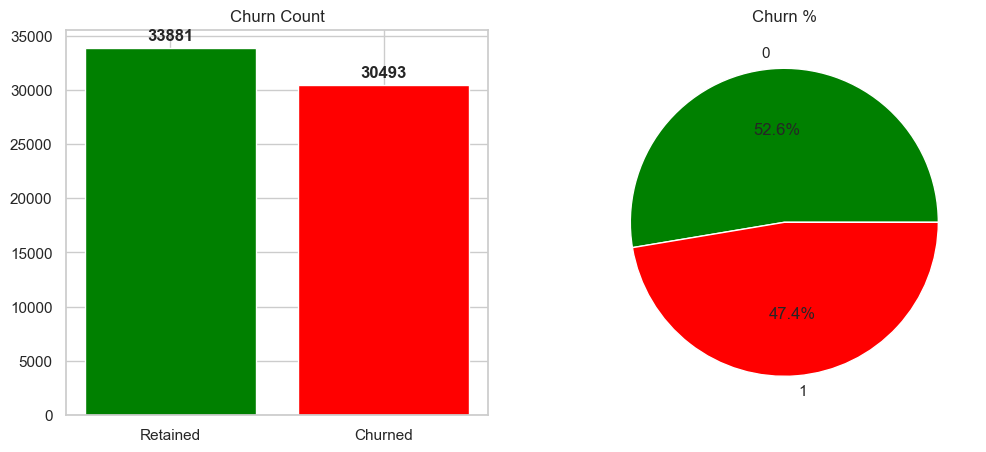

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


counts = df['Churn'].value_counts().sort_index()
bars = axes[0].bar(['Retained', 'Churned'], counts, color=['green', 'red'])
axes[0].bar_label(bars, padding=3, fontweight='bold')
axes[0].set_title('Churn Count')

axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['green', 'red'])
axes[1].set_title('Churn %')

plt.show()

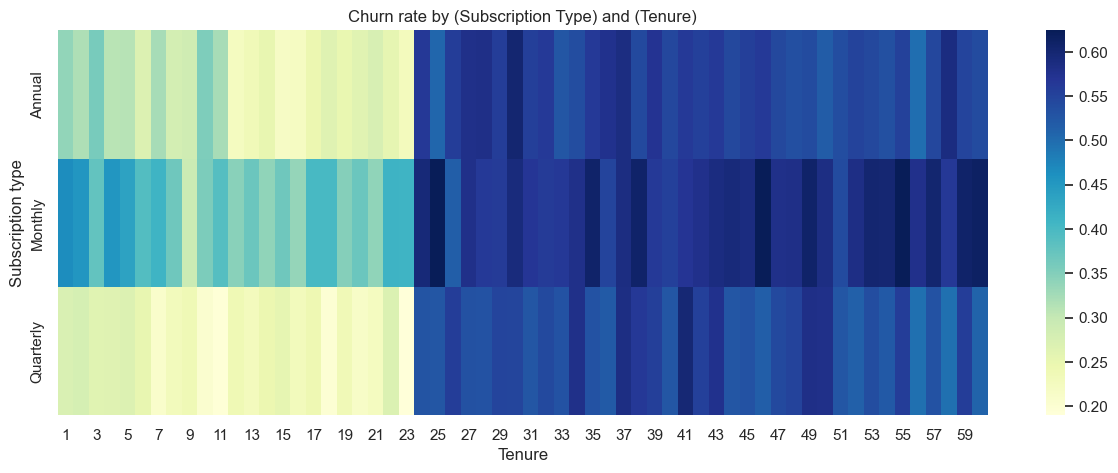

In [14]:
#Cohort Analysis (heatmap)
use_column = ['Tenure', 'Churn', 'Payment Delay', 'Support Calls', 'Contract Length', 'Subscription Type']
df_analysis = df[use_column].copy()

cohort_povit = df_analysis.pivot_table(index='Contract Length',columns='Tenure',values='Churn',aggfunc='mean')

plt.figure(figsize=(15,5))
sns.heatmap(cohort_povit,cmap='YlGnBu', annot=False)
plt.title('Churn rate by (Subscription Type) and (Tenure)')
plt.xlabel('Tenure')
plt.ylabel('Subscription type')
plt.show()


## Conclusion: Tenure and Subscription Risk:  
The analysis reveals a significant churn spike between the 23rd and 25th month, suggesting a critical period where customers re-evaluate their contracts. The Monthly Subscription remains the highest-risk segment, showing substantial customer loss both in the initial months and at the end of the lifecycle. To improve retention, the business should focus on loyalty incentives for monthly users before they reach the two-year mark.

Text(154.75, 0.5, 'Support Calls')

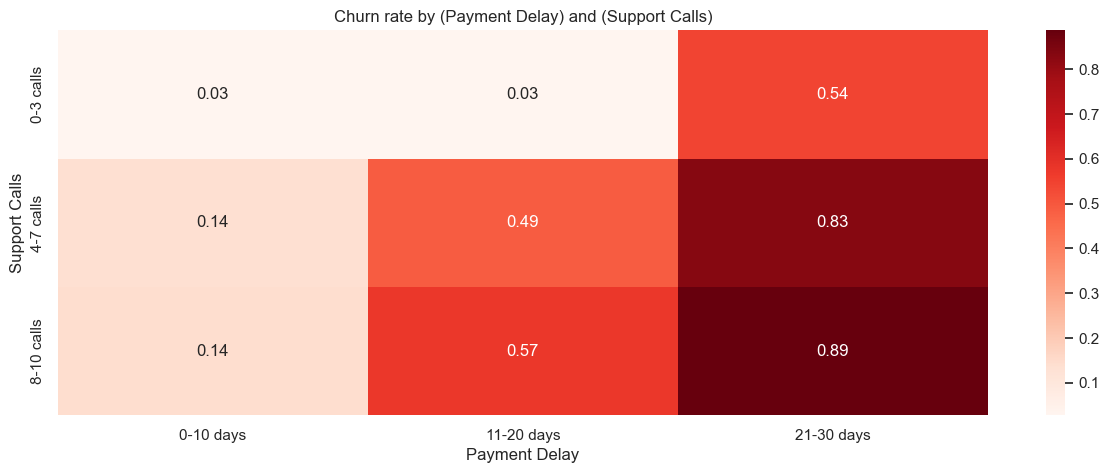

In [15]:
# Matrix of risk
#print(df_analysis['Payment Delay'].max())
#print(df_analysis['Support Calls'].max())

df_analysis['Group_Delay'] = pd.cut(df['Payment Delay'],
                                     bins=[0, 10, 20, 30],
                                     labels=['0-10 days', '11-20 days', '21-30 days'],
                                     include_lowest=True) 

df_analysis['Group_Calls'] = pd.cut(df['Support Calls'],
                                     bins=[0, 3, 7, 10],
                                     labels=['0-3 calls', '4-7 calls', '8-10 calls'],
                                     include_lowest=True)

#df_analysis['Goup_Delay']
#df_analysis['Goup_Calls']


risk_pivot = df_analysis.pivot_table(index='Group_Calls',columns='Group_Delay',values='Churn',aggfunc='mean')
plt.figure(figsize=(15,5))
sns.heatmap(risk_pivot,annot=True, fmt='.2f', cmap='Reds')
plt.title('Churn rate by (Payment Delay) and (Support Calls)')
plt.xlabel('Payment Delay')
plt.ylabel('Support Calls')



## Conclusion: Payment Delay Impact
There is a strong correlation between payment delays and churn, with the risk increasing sharply once the delay exceeds 20 days. This threshold represents a critical intervention point where proactive customer outreach could significantly reduce cancellation rates.

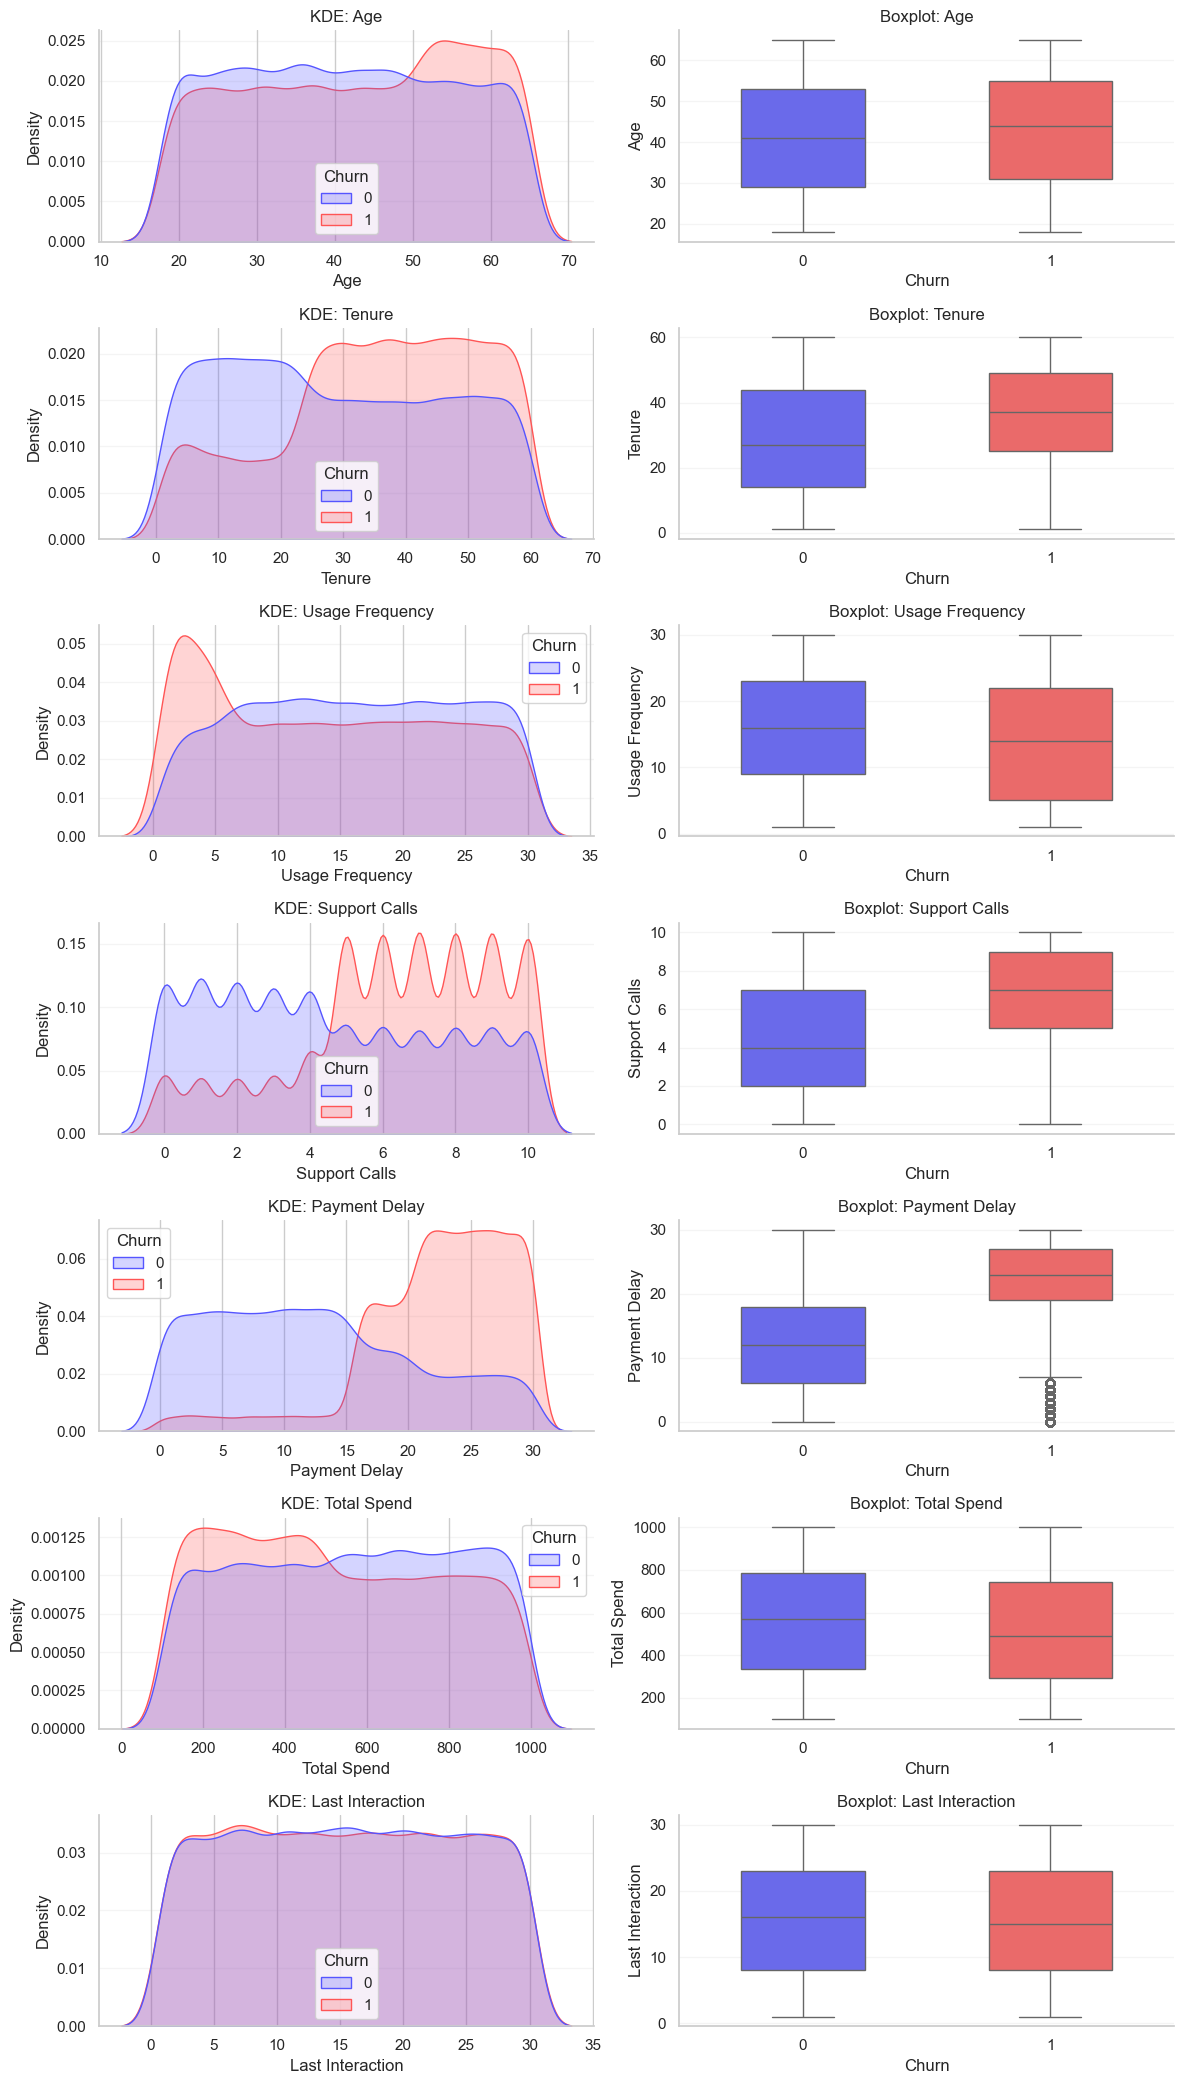

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 
            'Payment Delay', 'Total Spend', 'Last Interaction']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, ax=axes[i, 0], palette='seismic', common_norm=False)
    axes[i, 0].set_title(f'KDE: {col}')

    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i, 1], palette='seismic', width=0.5)
    axes[i, 1].set_title(f'Boxplot: {col}')
    
    for ax in axes[i]:
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

## 4. Model Training & Evaluation

In [17]:
models = {
    'AdaBoost' : AdaBoostClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(random_state= 42, class_weight = 'balanced')
}
result =[]
for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    result.append({
        'Model': name,
        'Accuracy': round(model.score(X_test, y_test),3),
        'ROC-AUC': round(roc_auc_score(y_test,y_prob),3),
        'F1': round(f1_score(y_test,y_pred),3),
        'Recall': round(recall_score(y_test,y_pred),3)
    }
    )

print(pd.DataFrame(result).to_string(index=False))

              Model  Accuracy  ROC-AUC    F1  Recall
           AdaBoost     0.874    0.946 0.868   0.881
      Random Forest     0.965    0.996 0.963   0.980
Logistic Regression     0.823    0.900 0.818   0.837


## Conclusion: Model Comparison
| Model               | Accuracy | ROC-AUC | F1    | Recall |
|---------------------|----------|---------|-------|--------|
| AdaBoost            | 0.874    | 0.946   | 0.868 | 0.881  |
| Random Forest       | 0.965    | 0.996   | 0.963 | 0.980  |
| Logistic Regression | 0.823    | 0.900   | 0.818 | 0.837  |

**Random Forest** delivered the strongest performance across all metrics,
achieving a near-perfect ROC-AUC of 0.996 and a Recall of 0.980 — meaning
it correctly identified 98% of customers who actually churned.

**AdaBoost** ranked second, showing solid results (AUC: 0.946, Recall: 0.881),
and remains a viable option when a lighter model is preferred.

**Logistic Regression** served as a useful baseline but fell short in all
categories, suggesting that the relationships between features and churn
are non-linear and benefit from ensemble methods.


In a churn context, missing a churner is more costly than a false alarm.
A customer incorrectly flagged for retention outreach costs a small incentive,
while a missed churner means permanent revenue loss. For this reason,
Recall is the primary metric — and Random Forest leads convincingly.


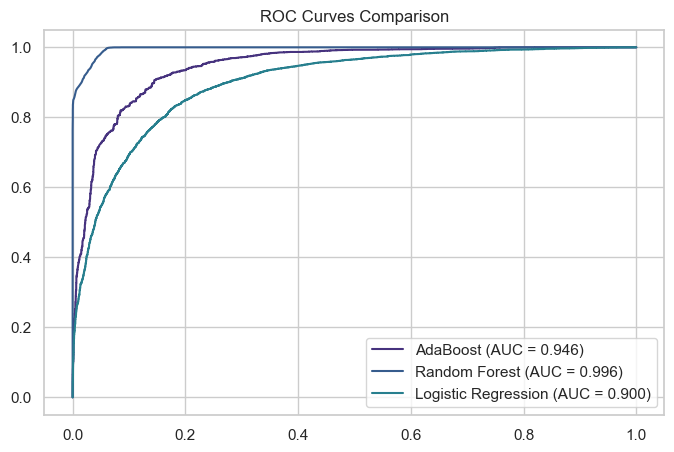

In [21]:
plt.figure(figsize=(8,5))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.3f})")

plt.title('ROC Curves Comparison')
plt.legend()
plt.show()